# [1] Imports & Motor-CAD 연결

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# [1] Imports & Motor-CAD 연결
# ─────────────────────────────────────────────────────────────────────────────
import pathlib
import sys
import importlib
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat

# Repo root on path
repo_root = pathlib.Path.cwd().resolve()
while not ((repo_root / "tools").exists() or (repo_root / "tool").exists()) and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# 패키지 reload (의존순서: model → plot → parse → facade)
import tools.motorCAD.pyMCAD.magnetic_model as _mm
import tools.motorCAD.pyMCAD.magnetic_plot as _mp
import tools.motorCAD.pyMCAD.magnetic_parse as _mparse
import tools.motorCAD.pyMCAD.magnetic as _mag
importlib.reload(_mm)
importlib.reload(_mp)
importlib.reload(_mparse)
importlib.reload(_mag)

from tools.motorCAD.pyMCAD import (
    get_magnetic_timeseries_from_file,
    mcad_default_export_dir,
    find_latest_mes,
    list_mes_files,
)
from tools.motorCAD.pyMCAD.magnetic_model import MagElement

import ansys.motorcad.core as pymotorcad

# Motor-CAD 연결
mcad = pymotorcad.MotorCAD(open_new_instance=False)
print("Motor-CAD connected")
print(f"  MOT file: {mcad.get_variable('CurrentMotFilePath_MotorLAB')}")

Motor-CAD connected
  MOT file: D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half.mot


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# [2] e10 모터 파라미터 설정
# ─────────────────────────────────────────────────────────────────────────────

# --- Conductor geometry (hairpin, rectangular) ---
# COND_WIDTH_MM = 2.5        # tangential width b [mm] (확인 필요 → Motor-CAD에서)
# COND_HEIGHT_MM = 2.5       # radial height h [mm] (확인 필요 → Motor-CAD에서)
SIGMA_CU = 5.8e7           # Cu conductivity @ 20°C [S/m]
# ACTIVE_LENGTH_MM = 100.0   # axial stack length [mm] (확인 필요)

# Motor-CAD에서 실제 값 읽기
try:
    COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))  # 슬롯 폭 / 병렬 수
    COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
    ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
    n_parallel = int(mcad.get_variable("ParallelPaths"))
    n_turns = int(mcad.get_variable("MagTurnsConductor"))
    print(f"  Conductor: {COND_WIDTH_MM:.2f} x {COND_HEIGHT_MM:.2f} mm")
    print(f"  Active length: {ACTIVE_LENGTH_MM:.1f} mm")
    print(f"  Parallel paths: {n_parallel}, Turns/conductor: {n_turns}")
except Exception as e:
    print(f"  [WARN] Motor-CAD variable read failed: {e}")
    print(f"  Using default values: {COND_WIDTH_MM} x {COND_HEIGHT_MM} mm, L={ACTIVE_LENGTH_MM} mm")

# Convert to SI
b_m = COND_WIDTH_MM * 1e-3     # conductor tangential width [m]
h_m = COND_HEIGHT_MM * 1e-3    # conductor radial height [m]
L_a = ACTIVE_LENGTH_MM * 1e-3  # active length [m]

# --- Operating conditions ---
POLE_PAIRS = 4                 # 8-pole motor
SPEED_LIST = [2000, 4000, 8000, 16000]  # RPM

# Electrical frequency per speed
def speed_to_fe(speed_rpm, pole_pairs=POLE_PAIRS):
    return pole_pairs * speed_rpm / 60.0

print(f"\n  Speed → f_e: {[(s, f'{speed_to_fe(s):.0f} Hz') for s in SPEED_LIST]}")

# --- Skin depth & ξ table ---
MU_0 = 4 * np.pi * 1e-7
print(f"\n{'Speed [RPM]':>12} {'f_e [Hz]':>10} {'δ [mm]':>10} {'ξ = h/δ':>10}")
print("-" * 50)
for spd in SPEED_LIST:
    fe = speed_to_fe(spd)
    delta = 1.0 / np.sqrt(np.pi * fe * MU_0 * SIGMA_CU)
    xi_val = h_m / delta
    print(f"{spd:>12} {fe:>10.0f} {delta*1e3:>10.2f} {xi_val:>10.3f}")

  Conductor: 5.57 x 2.53 mm
  Active length: 150.0 mm
  Parallel paths: 1, Turns/conductor: 1

  Speed → f_e: [(2000, '133 Hz'), (4000, '267 Hz'), (8000, '533 Hz'), (16000, '1067 Hz')]

 Speed [RPM]   f_e [Hz]     δ [mm]    ξ = h/δ
--------------------------------------------------
        2000        133       5.72      0.442
        4000        267       4.05      0.625
        8000        533       2.86      0.884
       16000       1067       2.02      1.250


## [3] FEA B-field Export (Hybrid Mode)

Motor-CAD를 Hybrid 모드(`ProximityLossModel=1`)로 설정하고 각 속도에서 FEA를 실행한 뒤,
시간 스텝별 B-field를 TXT로 내보냅니다.

> **이미 `backup_fea_result`로 백업이 있다면**, 아래 셀에서 직접 해당 txt를 로드해도 됩니다.  
> export 없이 기존 .mes → txt 변환도 가능합니다 (`mc.load_fea_result` + `mc.save_fea_data`).

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# [3] Hybrid FEA 실행 + B-field TXT Export (속도별)
# ─────────────────────────────────────────────────────────────────────────────
# 
# 옵션 A: Motor-CAD를 여기서 직접 실행
# 옵션 B: 이미 실행된 결과의 .mes를 로드하여 export만 수행
#
# 여기서는 옵션 A (실행 + export) 를 기본으로 합니다.
# 이미 결과가 있으면 DO_SOLVE=False로 설정하세요.

DO_SOLVE = True
PHASE_ADVANCE = 43.33
RMS_CURRENT = 460  # Ref model

# FEA export 설정
FIRST_STEP = 1
FINAL_STEP = mcad.get_variable("TorquePointsPerCycle")  # Motor-CAD 기본 TorquePointsPerCycle 정도
EXPORT_COLUMNS = "RegCode,Bx,By,A,J,Je"

out_root = Path(mcad_default_export_dir(mcad))
export_dir = out_root / "Hybrid_ACloss_Export"
export_dir.mkdir(parents=True, exist_ok=True)


In [ ]:

# 속도별 export 결과 저장
exported_files = {}  # {speed_rpm: Path}

# Hybrid Motor-CAD 결과도 저장
hybrid_results = {}  # {speed_rpm: {"total": W, "prox": W, "skin": W}}

mcad.set_variable("ProximityLossModel", 1)  # Hybrid
mcad.set_variable("RMSCurrent", RMS_CURRENT)
mcad.set_variable("PhaseAdvance", PHASE_ADVANCE)

for speed in SPEED_LIST:
    print(f"\n{'='*60}")
    print(f"  Speed = {speed} RPM (f_e = {speed_to_fe(speed):.0f} Hz)")
    print(f"{'='*60}")
    
    mcad.set_variable("ShaftSpeed", speed)
    
    if DO_SOLVE:
        print("  → Solving Hybrid FEA...")
        mcad.do_magnetic_calculation()
    
    # Hybrid 결과 읽기
    total_w = float(mcad.get_variable("ACLoss_Hybrid_Total"))
    prox_w = float(mcad.get_variable("ACLoss_Hybrid_Prox_Total"))
    skin_w = float(mcad.get_variable("ACLoss_Hybrid_SkinEffect_Total"))
    hybrid_results[speed] = {"total": total_w, "prox": prox_w, "skin": skin_w}
    print(f"  Hybrid Total={total_w:.1f} W, Prox={prox_w:.1f} W, Skin={skin_w:.1f} W")
    
    # B-field TXT export
    txt_name = f"Hybrid_{speed}RPM_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
    txt_path = export_dir / txt_name
    mcad.save_fea_data(str(txt_path), FIRST_STEP, FINAL_STEP, EXPORT_COLUMNS, "", ",")
    exported_files[speed] = txt_path
    print(f"  → Exported: {txt_path.name}")

print(f"\n✓ Export 완료: {len(exported_files)} files in {export_dir}")

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# [3b] FEResultsData_backup에서 .mes 파일 검색 → Motor-CAD 로드 → TXT export
# ─────────────────────────────────────────────────────────────────────────────
import re

def find_backup_mes_files(backup_root, speed_list=SPEED_LIST,
                          folder_pattern=r"Hybrid_.*Speed_(\d+)RPM",
                          mes_pattern="OnLoad*result*.mes",
                          latest_only=True):
    """
    FEResultsData_backup 하위에서 속도별 백업 .mes 파일을 검색.
    
    백업 폴더 구조 예시:
        FEResultsData_backup/
            Hybrid_Ref_Speed_2000RPM_20260609_171015/
                OnLoadTorque_result_1.mes
                ...
            Hybrid_Ref_Speed_4000RPM_20260609_172530/
                ...
    
    Args:
        backup_root: FEResultsData_backup 경로 (str | Path)
        speed_list: 찾을 속도 목록 [RPM]
        folder_pattern: 백업 폴더명 매칭 regex (그룹 1 = speed)
        mes_pattern: .mes 파일 glob 패턴
        latest_only: True면 속도별 가장 최신 폴더만 반환
    
    Returns:
        dict {speed_rpm: Path(.mes file)} (latest_only=True)
        dict {speed_rpm: [Path(.mes), ...]} (latest_only=False)
    """
    backup_root = Path(backup_root)
    if not backup_root.exists():
        print(f"  [WARN] Backup root not found: {backup_root}")
        return {}
    
    rx = re.compile(folder_pattern, re.IGNORECASE)
    speed_set = set(speed_list)
    candidates = {s: [] for s in speed_list}
    
    # 하위 폴더 순회
    for folder in backup_root.iterdir():
        if not folder.is_dir():
            continue
        m = rx.search(folder.name)
        if not m:
            continue
        speed_val = int(m.group(1))
        if speed_val not in speed_set:
            continue
        
        # 폴더 내 .mes 파일 검색
        mes_files = list(folder.glob(mes_pattern))
        if not mes_files:
            # fallback: 아무 .mes든 찾기
            mes_files = list(folder.glob("*.mes"))
        if mes_files:
            # 가장 큰 파일 (보통 OnLoadTorque가 가장 큼 = 시간 스텝 多)
            best_mes = max(mes_files, key=lambda p: p.stat().st_size)
            candidates[speed_val].append((folder, best_mes))
    
    # mtime 기준 정렬 (최신 폴더 먼저)
    for s in candidates:
        candidates[s].sort(key=lambda t: t[0].stat().st_mtime, reverse=True)
    
    if latest_only:
        return {s: paths[0][1] for s, paths in candidates.items() if paths}
    else:
        return {s: [p[1] for p in paths] for s, paths in candidates.items() if paths}


def export_mes_to_txt(mcad_obj, mes_path, txt_out_path, first_step=1, final_step=45,
                      columns="RegCode,Bx,By,A,J,Je"):
    """
    .mes 파일을 Motor-CAD에 로드한 뒤 TXT로 export.
    
    Args:
        mcad_obj: Motor-CAD 인스턴스
        mes_path: .mes 파일 경로
        txt_out_path: 출력 TXT 경로
        first_step: 시작 step
        final_step: 종료 step
        columns: export 컬럼
    
    Returns:
        Path: 저장된 TXT 경로
    """
    mes_path = Path(mes_path)
    txt_out_path = Path(txt_out_path)
    txt_out_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Motor-CAD에 .mes 로드
    mcad_obj.load_fea_result(str(mes_path), 1)
    
    # TXT export
    mcad_obj.save_fea_data(str(txt_out_path), first_step, final_step, columns, "", ",")
    return txt_out_path


# ── 검색 + Export 실행 ──
# Motor-CAD의 FEResultsData_backup 경로 자동 탐색
mot_path = Path(mcad.get_variable("CurrentMotFilePath_MotorLAB"))
fea_backup_root = mot_path.parent / mot_path.stem / "FEResultsData_backup"

# 다른 가능한 경로도 추가
alt_backup_roots = [
    fea_backup_root,
    mot_path.parent / "FEResultsData_backup",
    # Path(r"D:\KDH\ACLoss_E10\e10_26R1mot\FEResultsData_backup"),
]

print(f"Searching for backup .mes files...")
backup_mes = {}
for root in alt_backup_roots:
    if root.exists():
        found = find_backup_mes_files(root, SPEED_LIST)
        if found:
            backup_mes.update(found)
            print(f"  ✓ {root}: found {len(found)} speeds")
            break
    else:
        print(f"  ✗ {root} (not found)")

if backup_mes:
    print(f"\n{'Speed':>8} {'MES file':<60} {'Size':>8}")
    print("-" * 80)
    for spd, mes_p in sorted(backup_mes.items()):
        print(f"{spd:>8} {mes_p.name:<60} {mes_p.stat().st_size/1024:.0f} KB")
    
    # .mes → TXT export
    print(f"\nExporting .mes → TXT...")
    exported_files = {}
    for speed, mes_path in sorted(backup_mes.items()):
        txt_name = f"Hybrid_{speed}RPM_from_backup.txt"
        txt_path = export_dir / txt_name
        
        print(f"  {speed} RPM: {mes_path.name} → {txt_name}...", end=" ")
        export_mes_to_txt(mcad, mes_path, txt_path,
                          first_step=FIRST_STEP, final_step=FINAL_STEP,
                          columns=EXPORT_COLUMNS)
        exported_files[speed] = txt_path
        print(f"✓ ({txt_path.stat().st_size/1024:.0f} KB)")
    
    print(f"\n✓ Exported {len(exported_files)} TXT files to {export_dir}")
else:
    print("\n[WARN] No backup .mes files found. Run Cell [3] with DO_SOLVE=True first,")
    print("       or specify backup paths manually in alt_backup_roots.")

Searching for backup .mes files...
  ✓ D:\KangDH\Thesis\e10\SLFEA_Half\e10Turn6V261SLFEA_Half\FEResultsData_backup: found 4 speeds

   Speed MES file                                                         Size
--------------------------------------------------------------------------------
    2000 OnLoadTorque_result_1.mes                                    25553 KB
    4000 OnLoadTorque_result_1.mes                                    25553 KB
    8000 OnLoadTorque_result_1.mes                                    25553 KB
   16000 OnLoadTorque_result_1.mes                                    25553 KB

Exporting .mes → TXT...
  2000 RPM: OnLoadTorque_result_1.mes → Hybrid_2000RPM_from_backup.txt... ✓ (312914 KB)
  4000 RPM: OnLoadTorque_result_1.mes → Hybrid_4000RPM_from_backup.txt... ✓ (312914 KB)
  8000 RPM: OnLoadTorque_result_1.mes → Hybrid_8000RPM_from_backup.txt... ✓ (312914 KB)
  16000 RPM: OnLoadTorque_result_1.mes → Hybrid_16000RPM_from_backup.txt... ✓ (312914 KB)

✓ Exported 4

# [4] TXT 파싱 → 도체 RegCode 식별 → 요소 추출


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# [4] TXT 파싱 → 도체 RegCode 식별 → 요소 추출
# ─────────────────────────────────────────────────────────────────────────────
# 패키지 변경 반영을 위한 reload (의존순서대로)
import importlib
import tools.motorCAD.pyMCAD.magnetic_model as _mm
import tools.motorCAD.pyMCAD.magnetic_plot as _mp
import tools.motorCAD.pyMCAD.magnetic_parse as _mparse
import tools.motorCAD.pyMCAD.magnetic as _mag
importlib.reload(_mm)       # 1) model (클래스 정의)
importlib.reload(_mp)       # 2) plot (interactive 함수)
importlib.reload(_mparse)   # 3) parse (model을 import하므로 model 후에)
importlib.reload(_mag)      # 4) facade (parse, model을 re-export)

from tools.motorCAD.pyMCAD.magnetic import get_magnetic_timeseries_from_file

# 하나의 속도 파일을 먼저 파싱하여 RegCode 매핑 확인
test_speed = SPEED_LIST[0]
test_file = exported_files[test_speed]
print(f"Parsing: {test_file.name}")

ts = get_magnetic_timeseries_from_file(str(test_file), key="time_index", verbose=True)
print(f"  Steps: {len(ts.steps)}, range = [{ts.steps[0]}..{ts.steps[-1]}]")
print(f"  ts.interactive_plot available: {hasattr(ts, 'interactive_plot')}")
print(f"  ts.interactive_quiver available: {hasattr(ts, 'interactive_quiver')}")
print(f"  ts.export_gif available: {hasattr(ts, 'export_gif')}")

Parsing: Hybrid_2000RPM_from_backup.txt
Parsed block key=0: elements=18704, nodes=9623
Parsed block key=1: elements=18704, nodes=9626
Parsed block key=2: elements=18704, nodes=9629
Parsed block key=3: elements=18704, nodes=9632
Parsed block key=4: elements=18704, nodes=9635
Parsed block key=5: elements=18704, nodes=9638
Parsed block key=6: elements=18704, nodes=9641
Parsed block key=7: elements=18704, nodes=9644
Parsed block key=8: elements=18704, nodes=9647
Parsed block key=9: elements=18704, nodes=9650
Parsed block key=10: elements=18704, nodes=9653
Parsed block key=11: elements=18704, nodes=9656
Parsed block key=12: elements=18704, nodes=9659
Parsed block key=13: elements=18704, nodes=9662
Parsed block key=14: elements=18704, nodes=9665
Parsed block key=15: elements=18704, nodes=9668
Parsed block key=16: elements=18704, nodes=9671
Parsed block key=17: elements=18704, nodes=9674
Parsed block key=18: elements=18704, nodes=9677
Parsed block key=19: elements=18704, nodes=9680
Parsed blo

In [45]:
h_m

0.002529

In [ ]:
# ts 객체에서 바로 interactive 호출 (패키지 reload 후)
ts.interactive_plot(quantity="b", cmap="jet")


In [26]:

# 첫 번째 step의 MagneticRegions 구조 확인
mr0 = ts.by_step[ts.steps[0]]
print(f"  Total regions: {len(mr0._regions)}")
print(f"  Nodes with xy coords: {len(mr0.node_xy)}")

# RegCode별 요소 수 + 이름 출력
print(f"\n{'RegCode':>8} {'Elements':>10} {'Name'}")
print("-" * 50)
winding_reg_codes = []
for i, reg in enumerate(mr0._regions):
    n_el = len(reg.elements)
    if n_el == 0:
        continue
    # Winding region 식별: J != 0 인 요소가 있으면 도체
    has_current = any(abs(el.j) > 0.01 for el in reg.elements[:10])
    marker = " ← WINDING" if has_current else ""
    print(f"{reg.reg_code:>8} {n_el:>10} {reg.region_name}{marker}")
    if has_current:
        winding_reg_codes.append(reg.reg_code)

print(f"\n✓ Winding RegCodes: {winding_reg_codes}")
print(f"  Total winding elements: {sum(len(mr0._regions[rc-1].elements) for rc in winding_reg_codes)}")

  Total regions: 269
  Nodes with xy coords: 9623

 RegCode   Elements Name
--------------------------------------------------
       1       6480 Stator
       2         69 ArmatureSlotF1 ← WINDING
       3         63 ArmatureSlotA1 ← WINDING
       4         52 ArmatureSlotB1 ← WINDING
       5         52 ArmatureSlotC1 ← WINDING
       6         52 ArmatureSlotD1 ← WINDING
       7         52 ArmatureSlotE1 ← WINDING
       8        204 StatorWedge
       9        174 StatorAir
      10       3781 Rotor
      13        367 Rotor Pocket
      14        369 Rotor Pocket_1
      17        229 Rotor Pocket_2
      18        229 Rotor Pocket_3
      19        114 Shaft
      20        531 L1_1Magnet1N1
      21        508 L1_1Magnet2N1
      22        288 L2_1Magnet1N1
      23        288 L2_1Magnet2N1
      25        792 a1
      26        390 a2
      27        384 a3
      28        768 a4
      29        768 a5
      30         63 ArmatureSlotA2 ← WINDING
      31         63 Armature

# [5] 도체 요소 B-field 시계열 추출 + (Bx,By) → (Br,Bθ) 좌표 변환


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# [5] 도체 요소 B-field 시계열 추출 + (Bx,By) → (Br,Bθ) 좌표 변환
# ─────────────────────────────────────────────────────────────────────────────

def _triangle_area_mm2(n1_xy, n2_xy, n3_xy):
    """Shoelface formula로 삼각형 면적 [mm²] 계산."""
    x1, y1 = n1_xy
    x2, y2 = n2_xy
    x3, y3 = n3_xy
    return 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))


def extract_conductor_bfield_timeseries(ts, winding_reg_codes):
    """
    시간 스텝별로 도체 요소의 Bx, By를 추출하고 극좌표 변환.
    각 삼각형 요소의 면적도 함께 반환.
    
    Returns:
        dict with keys:
            'tri_indices': array of tri_index (n_elements,)
            'centroid_x': array (n_elements,) [mm]
            'centroid_y': array (n_elements,) [mm]
            'centroid_r': array (n_elements,) [mm]
            'centroid_theta': array (n_elements,) [rad]
            'element_area_mm2': array (n_elements,) [mm²]  ← NEW
            'element_area_m2': array (n_elements,) [m²]    ← NEW
            'bx': array (n_steps, n_elements) [T]
            'by': array (n_steps, n_elements) [T]
            'br': array (n_steps, n_elements) [T]  (radial)
            'bt': array (n_steps, n_elements) [T]  (tangential)
            'steps': list of step keys
            'times_s': array (n_steps,) [s] if available
    """
    steps = ts.steps
    mr0 = ts.by_step[steps[0]]
    
    # 도체 요소 목록 수집 (첫 step 기준)
    elements_info = []  # (reg_code, elem_idx_in_region, tri_index, cx, cy, area_mm2)
    for rc in winding_reg_codes:
        reg = mr0._regions[rc - 1]
        for i, el in enumerate(reg.elements):
            cx_cy = mr0._element_centroid_xy(el)
            if cx_cy is None:
                continue
            # 삼각형 면적 계산 (node_1, node_2, node_3의 좌표)
            n1 = mr0.node_xy.get(el.node_1)
            n2 = mr0.node_xy.get(el.node_2)
            n3 = mr0.node_xy.get(el.node_3)
            if n1 is not None and n2 is not None and n3 is not None:
                area_mm2 = _triangle_area_mm2(n1, n2, n3)
            else:
                area_mm2 = 0.0
            elements_info.append((rc, i, el.tri_index, cx_cy[0], cx_cy[1], area_mm2))
    
    n_elem = len(elements_info)
    n_steps = len(steps)
    print(f"  Conductor elements: {n_elem}, Time steps: {n_steps}")
    
    # 배열 초기화
    tri_indices = np.array([info[2] for info in elements_info], dtype=int)
    cx = np.array([info[3] for info in elements_info])  # [mm]
    cy = np.array([info[4] for info in elements_info])  # [mm]
    area_mm2 = np.array([info[5] for info in elements_info])  # [mm²]
    area_m2 = area_mm2 * 1e-6  # [m²]
    
    # 극좌표 (모터 중심 = 원점 가정)
    cr = np.sqrt(cx**2 + cy**2)  # [mm]
    ctheta = np.arctan2(cy, cx)  # [rad]
    
    # B-field 시계열 수집
    bx_arr = np.zeros((n_steps, n_elem))
    by_arr = np.zeros((n_steps, n_elem))
    times_s = np.zeros(n_steps)
    
    for si, step_key in enumerate(steps):
        mr = ts.by_step[step_key]
        meta = ts.meta.get(step_key, {})
        times_s[si] = meta.get("time_s", si)  # 시간 정보가 있으면 사용
        
        for ei, (rc, elem_idx, tri_idx, _, _, _) in enumerate(elements_info):
            el = mr._regions[rc - 1].elements[elem_idx]
            bx_arr[si, ei] = el.bx if el.bx is not None else 0.0
            by_arr[si, ei] = el.by if el.by is not None else 0.0
    
    # (Bx, By) → (Br, Bθ) 변환
    # Br = Bx·cos(θ) + By·sin(θ)
    # Bθ = -Bx·sin(θ) + By·cos(θ)
    cos_theta = np.cos(ctheta)  # (n_elem,)
    sin_theta = np.sin(ctheta)  # (n_elem,)
    
    br_arr = bx_arr * cos_theta[np.newaxis, :] + by_arr * sin_theta[np.newaxis, :]
    bt_arr = -bx_arr * sin_theta[np.newaxis, :] + by_arr * cos_theta[np.newaxis, :]
    
    print(f"  Element areas: min={area_mm2.min():.4f}, max={area_mm2.max():.4f}, "
          f"total={area_mm2.sum():.2f} mm² (≈ {area_mm2.sum()/(b_m*h_m*1e6):.1f} conductors)")
    
    return {
        'tri_indices': tri_indices,
        'centroid_x': cx,
        'centroid_y': cy,
        'centroid_r': cr,
        'centroid_theta': ctheta,
        'element_area_mm2': area_mm2,
        'element_area_m2': area_m2,
        'bx': bx_arr,
        'by': by_arr,
        'br': br_arr,
        'bt': bt_arr,
        'steps': steps,
        'times_s': times_s,
    }


# 테스트 실행
print(f"Extracting B-field from {test_file.name}...")
bfield_data = extract_conductor_bfield_timeseries(ts, winding_reg_codes)

print(f"\n  Br range: [{bfield_data['br'].min():.4f}, {bfield_data['br'].max():.4f}] T")
print(f"  Bθ range: [{bfield_data['bt'].min():.4f}, {bfield_data['bt'].max():.4f}] T")
print(f"  |B| max:  {np.sqrt(bfield_data['bx']**2 + bfield_data['by']**2).max():.4f} T")

Extracting B-field from Hybrid_2000RPM_from_backup.txt...
  Conductor elements: 2040, Time steps: 128
  Element areas: min=0.0504, max=1.1611, total=784.53 mm² (≈ 55.7 conductors)

  Br range: [-1.3805, 1.3805] T
  Bθ range: [-1.1911, 1.1911] T
  |B| max:  1.5293 T


# [6] FFT 고조파 분해 + El Hajji 2D 손실 계산 함수


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# [6] FFT 고조파 분해 + El Hajji 2D 손실 계산 함수
# ─────────────────────────────────────────────────────────────────────────────

def fft_harmonic_amplitudes(signal, dt, n_harmonics=20):
    """
    시간 도메인 신호를 FFT하여 고조파 진폭을 반환.
    
    Args:
        signal: (n_steps,) 시간 도메인 신호
        dt: 샘플 간격 [s]
        n_harmonics: 반환할 고조파 수 (DC 제외)
    
    Returns:
        freqs: (n_harmonics,) 주파수 [Hz]
        amplitudes: (n_harmonics,) 진폭 (peak, not RMS)
    """
    N = len(signal)
    spectrum = np.fft.rfft(signal)
    magnitudes = 2.0 * np.abs(spectrum) / N  # peak amplitude
    magnitudes[0] /= 2.0  # DC component
    
    freqs = np.fft.rfftfreq(N, d=dt)
    
    # DC 제외, 상위 n_harmonics개
    n_return = min(n_harmonics, len(freqs) - 1)
    return freqs[1:n_return+1], magnitudes[1:n_return+1]


def calculate_el_hajji_loss_2d(bfield_data, f_e, sigma, b_m, h_m, L_a, 
                                n_harmonics=20, n_slots_model=6, n_slots_total=48):
    """
    El Hajji 2D 후처리: 요소별 B-field로부터 체적 손실밀도 적분.
    
    El Hajji 공식 (전체 도체, uniform B 가정):
        P_cond = σ·L·ω²·(Br²·b·h³/24 + Bθ²·b³·h/24)
    
    체적 손실밀도 (average over conductor):
        q_r = σ·ω²·Br²·h²/24  [W/m³]  (radial field → eddy loops across h)
        q_t = σ·ω²·Bθ²·b²/24  [W/m³]  (tangential field → eddy loops across b)
    
    요소별 적용:
        P_elem = q · V_elem = σ·ω²·Br²·h²/24 · A_elem · L
    
    이 방식은 B가 도체 내에서 비균일할 때 정확한 면적가중 적분에 해당:
        Σ P_elem = σ·L·ω²·h²/24 · Σ(Br_i²·A_i) = σ·L·ω²·<Br²>·b·h³/24
    
    Args:
        bfield_data: extract_conductor_bfield_timeseries() 결과 (element_area_m2 포함)
        f_e: 기본 전기 주파수 [Hz]
        sigma: 도전율 [S/m]
        b_m: 도체 tangential 폭 [m]
        h_m: 도체 radial 높이 [m]
        L_a: 적층장 [m]
        n_harmonics: FFT에서 고려할 고조파 수
        n_slots_model: FEA 모델의 슬롯 수 (1/8 대칭이면 6)
        n_slots_total: 전체 모터 슬롯 수 (48)
    
    Returns:
        dict:
            'P_total_W': 전체 모터 proximity loss [W] (대칭 스케일 포함)
            'P_radial_W': radial 성분 합 [W]
            'P_tangential_W': tangential 성분 합 [W]
            'P_per_element': (n_elem,) 요소별 손실 [W] (모델 영역 기준)
            'P_per_harmonic': (n_harmonics,) 고조파별 손실 합 [W] (전체 모터)
            'freqs': (n_harmonics,) 고조파 주파수 [Hz]
            'symmetry_factor': 대칭 배수
    """
    br = bfield_data['br']  # (n_steps, n_elem)
    bt = bfield_data['bt']  # (n_steps, n_elem)
    A_elem = bfield_data['element_area_m2']  # (n_elem,) [m²]
    n_steps, n_elem = br.shape
    
    # 대칭 스케일링 팩터
    symmetry_factor = n_slots_total / n_slots_model
    
    # 시간 간격 계산
    times_s = bfield_data['times_s']
    if times_s[-1] > times_s[0]:
        dt = (times_s[-1] - times_s[0]) / (n_steps - 1)
    else:
        # 시간 정보가 없으면 전기 주기 기준
        T_e = 1.0 / f_e
        dt = T_e / n_steps
    
    # 요소별 + 고조파별 손실 계산
    P_per_element = np.zeros(n_elem)
    P_radial_per_element = np.zeros(n_elem)
    P_tangential_per_element = np.zeros(n_elem)
    P_per_harmonic = np.zeros(n_harmonics)
    freqs_out = np.zeros(n_harmonics)
    
    for ei in range(n_elem):
        # 해당 요소의 Br(t), Bθ(t)에 대해 FFT
        freqs_r, amp_r = fft_harmonic_amplitudes(br[:, ei], dt, n_harmonics)
        freqs_t, amp_t = fft_harmonic_amplitudes(bt[:, ei], dt, n_harmonics)
        
        if ei == 0:
            freqs_out[:len(freqs_r)] = freqs_r
        
        # 고조파별 El Hajji 손실 (체적손실밀도 × 요소체적)
        # P_r_elem = σ·ω²·Br²·h²/24 · A_elem · L  (radial field)
        # P_t_elem = σ·ω²·Bθ²·b²/24 · A_elem · L  (tangential field)
        for hi in range(min(len(freqs_r), n_harmonics)):
            omega_i = 2 * np.pi * freqs_r[hi]
            
            # 체적손실밀도 형태: q = σ·ω²·B²·d²/24, P = q·A_elem·L
            p_r = sigma * omega_i**2 * amp_r[hi]**2 * h_m**2 / 24.0 * A_elem[ei] * L_a
            p_t = sigma * omega_i**2 * amp_t[hi]**2 * b_m**2 / 24.0 * A_elem[ei] * L_a
            
            P_per_element[ei] += p_r + p_t
            P_radial_per_element[ei] += p_r
            P_tangential_per_element[ei] += p_t
            P_per_harmonic[hi] += p_r + p_t
    
    # 모델 영역 합산 → 전체 모터 스케일링
    P_total = P_per_element.sum() * symmetry_factor
    P_radial = P_radial_per_element.sum() * symmetry_factor
    P_tangential = P_tangential_per_element.sum() * symmetry_factor
    P_per_harmonic *= symmetry_factor
    
    return {
        'P_total_W': P_total,
        'P_radial_W': P_radial,
        'P_tangential_W': P_tangential,
        'P_per_element': P_per_element,  # 모델 영역 기준 (스케일 전)
        'P_per_harmonic': P_per_harmonic,
        'P_radial_per_element': P_radial_per_element,
        'P_tangential_per_element': P_tangential_per_element,
        'freqs': freqs_out,
        'symmetry_factor': symmetry_factor,
    }


# G_rect correction (Ferreira) — for ξ > 0.5
def G_rect(xi_val):
    """Ferreira correction for rectangular conductor proximity effect."""
    if xi_val < 1e-6:
        return 1.0
    return xi_val * (np.sinh(xi_val) + np.sin(xi_val)) / (np.cosh(xi_val) + np.cos(xi_val))


print("✓ El Hajji 2D loss functions defined (area-weighted density formulation)")
print(f"  G_rect(0.5) = {G_rect(0.5):.4f}")
print(f"  G_rect(1.0) = {G_rect(1.0):.4f}")
print(f"  G_rect(1.5) = {G_rect(1.5):.4f}")
print(f"  Symmetry: {48}/{6} = ×8 (1/8 periodic model)")
print(f"\n  공식 검증:")
print(f"    (old) P = σ·L·ω²·B²·b·h³/24     ← 도체 1개, uniform B")
print(f"    (new) P = σ·ω²·B²·h²/24 · A_elem · L   ← 요소별 적분")
print(f"    Σ(new) = σ·L·ω²·h²/24 · Σ(B²·A) = σ·L·ω²·<B²>·(b·h)·h²/24 = old식과 동치")

✓ El Hajji 2D loss functions defined (area-weighted density formulation)
  G_rect(0.5) = 0.2495
  G_rect(1.0) = 0.9680
  G_rect(1.5) = 1.9356
  Symmetry: 48/6 = ×8 (1/8 periodic model)

  공식 검증:
    (old) P = σ·L·ω²·B²·b·h³/24     ← 도체 1개, uniform B
    (new) P = σ·ω²·B²·h²/24 · A_elem · L   ← 요소별 적분
    Σ(new) = σ·L·ω²·h²/24 · Σ(B²·A) = σ·L·ω²·<B²>·(b·h)·h²/24 = old식과 동치


# [7] 전 속도 El Hajji 2D 계산 실행


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# [7] 전 속도 El Hajji 2D 계산 실행
# ─────────────────────────────────────────────────────────────────────────────

el_hajji_results = {}  # {speed_rpm: result_dict}

for speed in SPEED_LIST:
    if speed not in exported_files:
        print(f"  [SKIP] {speed} RPM — no exported file")
        continue
    
    print(f"\n{'─'*50}")
    print(f"  {speed} RPM (f_e = {speed_to_fe(speed):.0f} Hz)")
    
    # 파싱
    txt_path = exported_files[speed]
    ts_spd = get_magnetic_timeseries_from_file(str(txt_path), key="time_index")
    
    # B-field 추출
    bdata = extract_conductor_bfield_timeseries(ts_spd, winding_reg_codes)
    
    # El Hajji 2D 계산
    fe = speed_to_fe(speed)
    result = calculate_el_hajji_loss_2d(
        bdata, f_e=fe, sigma=SIGMA_CU,
        b_m=b_m, h_m=h_m, L_a=L_a,
        n_harmonics=48, n_slots_model=6,
    )
    
    # G_rect correction 적용
    delta = 1.0 / np.sqrt(np.pi * fe * MU_0 * SIGMA_CU)
    xi_val = h_m / delta
    g_corr = G_rect(xi_val)
    result['P_total_corrected_W'] = result['P_total_W'] * g_corr
    result['G_rect'] = g_corr
    result['xi'] = xi_val
    
    el_hajji_results[speed] = result
    
    # # Motor-CAD Hybrid 대비 비교
    # hyb = hybrid_results.get(speed, {})
    # hyb_total = hyb.get('total', 0)
    # ratio = result['P_total_W'] / hyb_total if hyb_total > 0 else float('nan')
    # ratio_corr = result['P_total_corrected_W'] / hyb_total if hyb_total > 0 else float('nan')
    
    print(f"  El Hajji (raw):       {result['P_total_W']:.1f} W")
    print(f"  El Hajji (G_rect):    {result['P_total_corrected_W']:.1f} W  (G={g_corr:.4f}, ξ={xi_val:.3f})")
    # print(f"  Motor-CAD Hybrid:     {hyb_total:.1f} W")
    # print(f"  El Hajji/Hybrid:      {ratio:.4f} (raw), {ratio_corr:.4f} (corrected)")
    # print(f"  Radial/Tangential:    {result['P_radial_W']:.1f} / {result['P_tangential_W']:.1f} W")

print(f"\n✓ 전 속도 El Hajji 계산 완료")


──────────────────────────────────────────────────
  2000 RPM (f_e = 133 Hz)
  Conductor elements: 2040, Time steps: 128
  Element areas: min=0.0504, max=1.1611, total=784.53 mm² (≈ 55.7 conductors)
  El Hajji (raw):       20749.5 W
  El Hajji (G_rect):    4046.5 W  (G=0.1950, ξ=0.442)

──────────────────────────────────────────────────
  4000 RPM (f_e = 267 Hz)
  Conductor elements: 2040, Time steps: 128
  Element areas: min=0.0504, max=1.1611, total=784.53 mm² (≈ 55.7 conductors)
  El Hajji (raw):       83039.3 W
  El Hajji (G_rect):    32265.5 W  (G=0.3886, ξ=0.625)

──────────────────────────────────────────────────
  8000 RPM (f_e = 533 Hz)
  Conductor elements: 2040, Time steps: 128
  Element areas: min=0.0504, max=1.1611, total=784.53 mm² (≈ 55.7 conductors)
  El Hajji (raw):       332451.2 W
  El Hajji (G_rect):    254512.7 W  (G=0.7656, ξ=0.884)

──────────────────────────────────────────────────
  16000 RPM (f_e = 1067 Hz)
  Conductor elements: 2040, Time steps: 128
  Elemen

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# [8] 비교 Plot: El Hajji 2D vs Motor-CAD Hybrid vs TS
# ─────────────────────────────────────────────────────────────────────────────

# 기존 MAT 파일 로드 (TS + Hybrid 결과 포함)
MAT_PATH = Path(r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET_ACLoss_Comparison_20260609_223109.mat")
mat_data = None
if MAT_PATH.exists():
    mat_data = loadmat(str(MAT_PATH))
    print(f"  MAT loaded: {MAT_PATH.name}")
    print(f"  Keys: {[k for k in mat_data if not k.startswith('__')]}")
    ref_ts_active = mat_data["ref_ts_ActiveOnly_kW"].flatten()  # kW
else:
    print(f"  [WARN] MAT file not found: {MAT_PATH}")
    ref_ts_active = None

# ── hybrid_results를 MAT에서 구성 (kW 단위 → W 변환) ──
hybrid_results = {}
if mat_data is not None:
    _hyb_total_kw = mat_data["ref_hybrid_Total_kW"].flatten()  # (4,) kW
    _hyb_prox_kw = mat_data["ref_hybrid_Prox_kW"].flatten()
    _hyb_skin_kw = mat_data["ref_hybrid_Skin_kW"].flatten()
    for i, spd in enumerate(SPEED_LIST):
        hybrid_results[spd] = {
            "total": _hyb_total_kw[i] * 1000.0,  # W
            "prox": _hyb_prox_kw[i] * 1000.0,
            "skin": _hyb_skin_kw[i] * 1000.0,
        }
    print(f"  hybrid_results loaded from MAT: {list(hybrid_results.keys())}")


  MAT loaded: JEET_ACLoss_Comparison_20260609_223109.mat
  Keys: ['speeds_RPM', 'RMS_Current_Ref_A', 'RMS_Current_SC_A', 'ref_hybrid_Total_kW', 'ref_hybrid_Prox_kW', 'ref_hybrid_Skin_kW', 'sc_hybrid_Total_kW', 'sc_hybrid_Prox_kW', 'sc_hybrid_Skin_kW', 'ref_ts_OnLoad_PerTurn_kW', 'ref_ts_ActiveOnly_kW', 'ref_ts_Total_kW', 'ref_ts_DC_Active_kW', 'ref_ts_DC_End_kW', 'sc_ts_OnLoad_PerTurn_kW', 'sc_ts_ActiveOnly_kW', 'sc_ts_Total_kW', 'sc_ts_DC_Active_kW', 'sc_ts_DC_End_kW', 'sc2ref_Hybrid_ratio', 'sc2ref_TS_ratio', 'hyb_AC_ratio', 'hyb_Prox_ratio', 'hyb_Skin_ratio', 'ts2hyb_Ref_ratio', 'ts2hyb_SC_ratio', 'ref_AC_DC_ratio_TS', 'sc_AC_DC_ratio_TS', 'ref_AC_DC_ratio_Hyb', 'sc_AC_DC_ratio_Hyb', 'halfsc_hybrid_Total_kW', 'halfsc_ts_ActiveOnly_kW', 'halfsc_hybrid_Prox_kW', 'halfsc_hybrid_Skin_kW', 'halfsc_ts_OnLoad_PerTurn_kW', 'halfsc_ts_Total_kW', 'halfsc_ts_DC_Active_kW', 'halfsc_ts_DC_End_kW', 'RMS_Current_HalfSC_A']
  hybrid_results loaded from MAT: [2000, 4000, 8000, 16000]


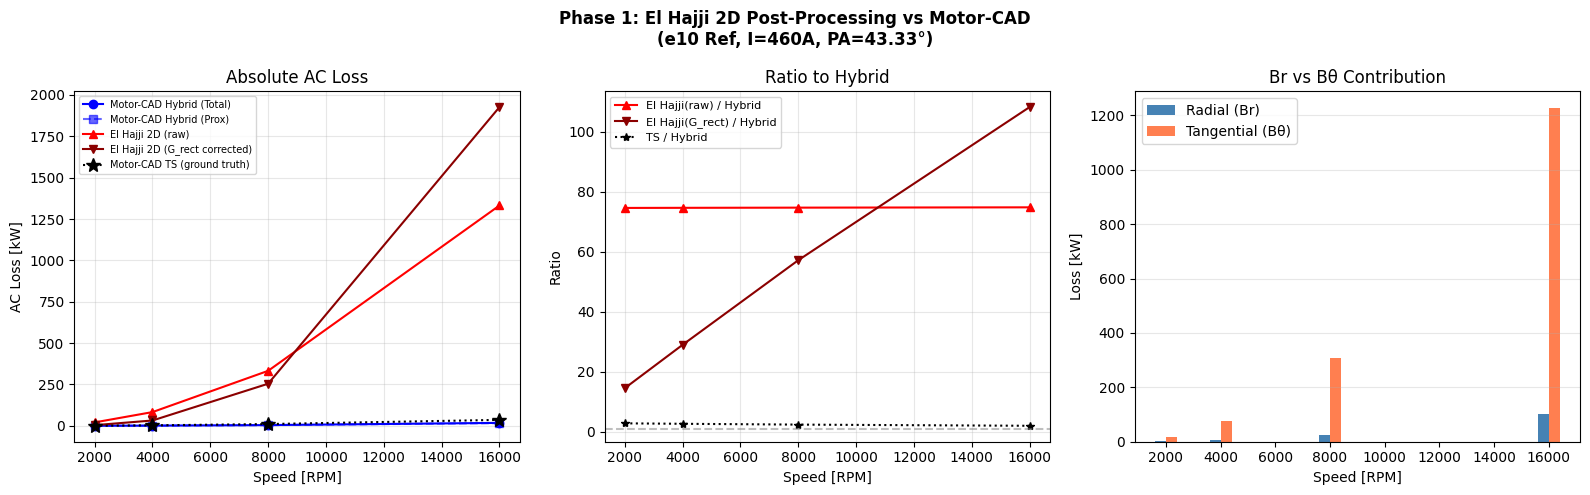

✓ Plot saved: D:\KangDH\Thesis\e10\SLFEA_Half\Hybrid_ACloss_Export\ElHajji_vs_Hybrid_Comparison.png


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# [8b] 3-Panel 비교: El Hajji 2D vs Motor-CAD Hybrid vs TS
# ─────────────────────────────────────────────────────────────────────────────

speeds = np.array(SPEED_LIST)

# El Hajji 결과 배열화
elhajji_raw = np.array([el_hajji_results[s]['P_total_W'] / 1000.0 for s in SPEED_LIST])  # kW
elhajji_corr = np.array([el_hajji_results[s]['P_total_corrected_W'] / 1000.0 for s in SPEED_LIST])  # kW
elhajji_radial = np.array([el_hajji_results[s]['P_radial_W'] / 1000.0 for s in SPEED_LIST])
elhajji_tangential = np.array([el_hajji_results[s]['P_tangential_W'] / 1000.0 for s in SPEED_LIST])

# Hybrid 결과 (MAT에서 로드됨, W 단위)
hybrid_total_kw = np.array([hybrid_results[s]['total'] / 1000.0 for s in SPEED_LIST])
hybrid_prox_kw = np.array([hybrid_results[s]['prox'] / 1000.0 for s in SPEED_LIST])

# ── Figure: 3-panel comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phase 1: El Hajji 2D Post-Processing vs Motor-CAD\n"
             f"(e10 Ref, I={RMS_CURRENT}A, PA={PHASE_ADVANCE}°)", fontsize=12, fontweight="bold")

# [Left] Absolute comparison
ax = axes[0]
ax.plot(speeds, hybrid_total_kw, '-o', color='blue', label='Motor-CAD Hybrid (Total)')
ax.plot(speeds, hybrid_prox_kw, '--s', color='blue', alpha=0.6, label='Motor-CAD Hybrid (Prox)')
ax.plot(speeds, elhajji_raw, '-^', color='red', label='El Hajji 2D (raw)')
ax.plot(speeds, elhajji_corr, '-v', color='darkred', label='El Hajji 2D (G_rect corrected)')
if ref_ts_active is not None:
    ax.plot(speeds, ref_ts_active, ':*', color='black', markersize=10, label='Motor-CAD TS (ground truth)')
ax.set_xlabel("Speed [RPM]")
ax.set_ylabel("AC Loss [kW]")
ax.set_title("Absolute AC Loss")
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

# [Center] Ratio to Hybrid
ax = axes[1]
ratio_raw = elhajji_raw / hybrid_total_kw
ratio_corr = elhajji_corr / hybrid_total_kw
ax.plot(speeds, ratio_raw, '-^', color='red', label='El Hajji(raw) / Hybrid')
ax.plot(speeds, ratio_corr, '-v', color='darkred', label='El Hajji(G_rect) / Hybrid')
if ref_ts_active is not None:
    ts_hyb_ratio = ref_ts_active / hybrid_total_kw
    ax.plot(speeds, ts_hyb_ratio, ':*', color='black', label='TS / Hybrid')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Speed [RPM]")
ax.set_ylabel("Ratio")
ax.set_title("Ratio to Hybrid")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# [Right] Radial vs Tangential decomposition
ax = axes[2]
ax.bar(speeds - 200, elhajji_radial, width=400, color='steelblue', label='Radial (Br)')
ax.bar(speeds + 200, elhajji_tangential, width=400, color='coral', label='Tangential (Bθ)')
ax.set_xlabel("Speed [RPM]")
ax.set_ylabel("Loss [kW]")
ax.set_title("Br vs Bθ Contribution")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(str(export_dir / "ElHajji_vs_Hybrid_Comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Plot saved: {export_dir / 'ElHajji_vs_Hybrid_Comparison.png'}")

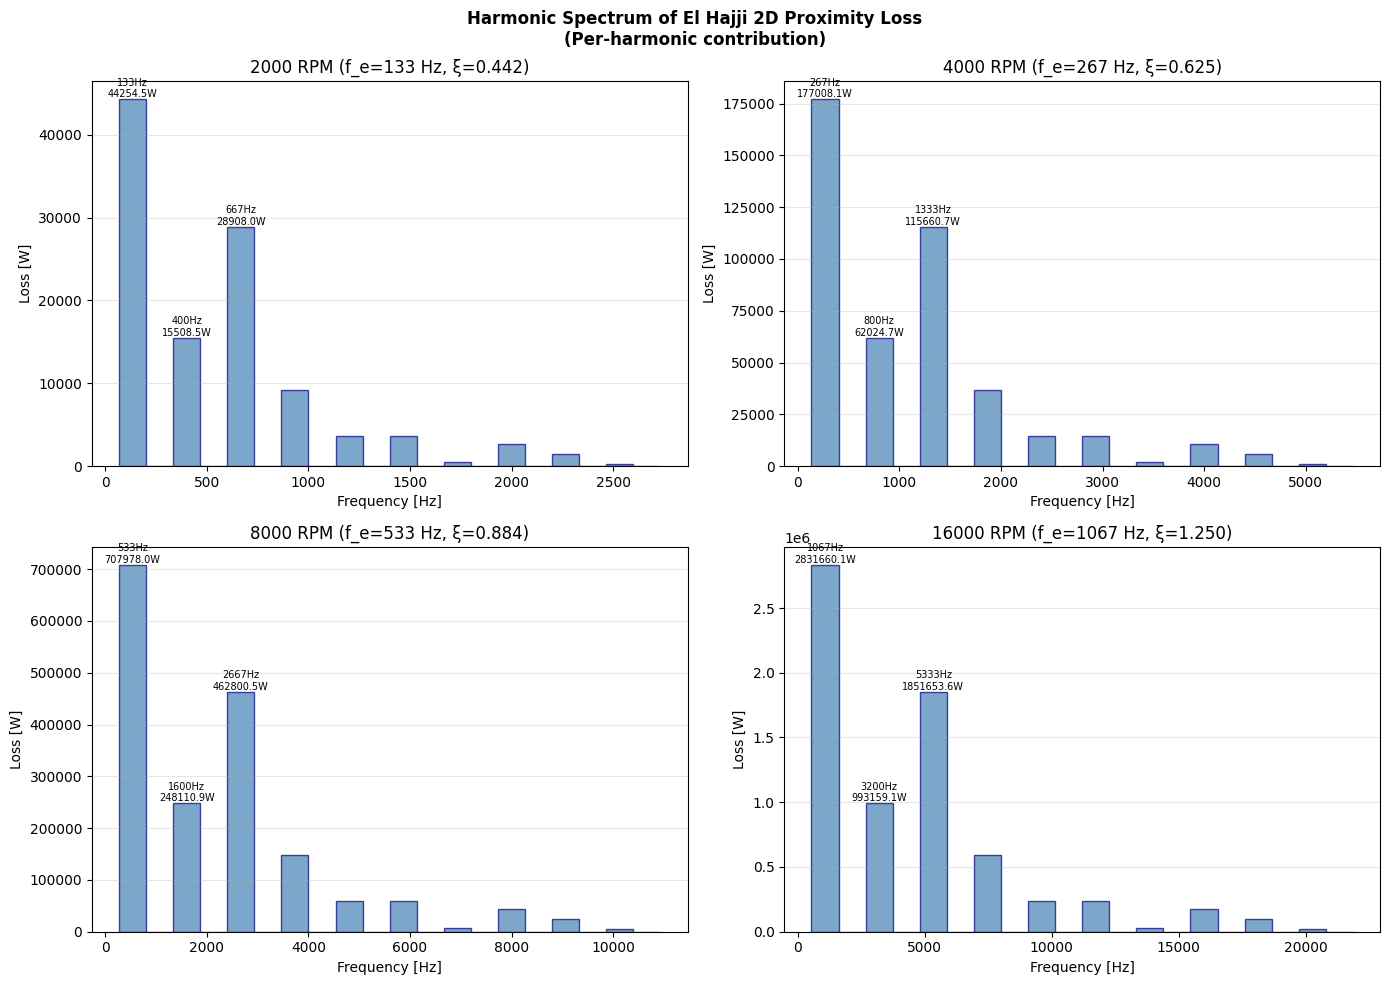

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# [9] 고조파 스펙트럼 분석 (대표 속도)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Harmonic Spectrum of El Hajji 2D Proximity Loss\n(Per-harmonic contribution)", 
             fontsize=12, fontweight="bold")

for idx, speed in enumerate(SPEED_LIST):
    ax = axes[idx // 2, idx % 2]
    result = el_hajji_results[speed]
    freqs = result['freqs']
    p_harm = result['P_per_harmonic']
    
    # 유효 고조파만 (0이 아닌 것)
    mask = p_harm > 0
    if mask.any():
        ax.bar(freqs[mask], p_harm[mask], width=freqs[1]-freqs[0] if len(freqs) > 1 else 50,
               color='steelblue', edgecolor='navy', alpha=0.7)
    
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Loss [W]")
    ax.set_title(f"{speed} RPM (f_e={speed_to_fe(speed):.0f} Hz, ξ={result['xi']:.3f})")
    ax.grid(True, alpha=0.3, axis='y')
    
    # 상위 3개 고조파 annotate
    top3 = np.argsort(p_harm)[-3:][::-1]
    for ti in top3:
        if p_harm[ti] > 0:
            ax.annotate(f"{freqs[ti]:.0f}Hz\n{p_harm[ti]:.1f}W",
                       xy=(freqs[ti], p_harm[ti]),
                       fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig(str(export_dir / "ElHajji_Harmonic_Spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

  Conductor elements: 2040, Time steps: 128
  Conductor elements: 2040, Time steps: 128
  Conductor elements: 2040, Time steps: 128
  Conductor elements: 2040, Time steps: 128


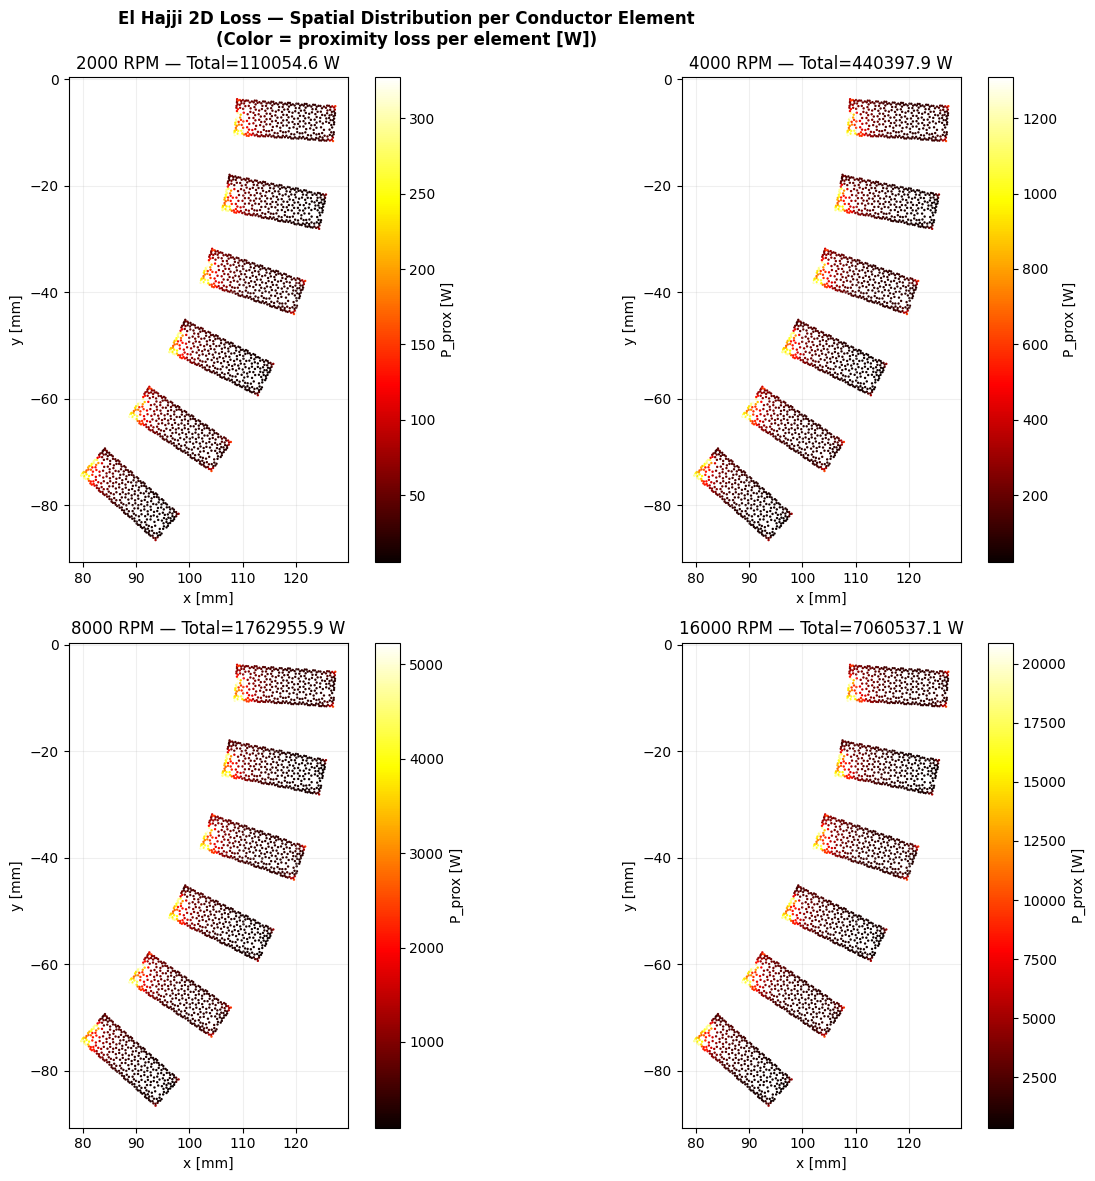

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# [10] 요소별 손실 분포 시각화 (Spatial Distribution)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("El Hajji 2D Loss — Spatial Distribution per Conductor Element\n"
             "(Color = proximity loss per element [W])", fontsize=12, fontweight="bold")

for idx, speed in enumerate(SPEED_LIST):
    ax = axes[idx // 2, idx % 2]
    result = el_hajji_results[speed]
    
    # 해당 속도의 bfield_data에서 centroid 좌표 사용
    # (이미 계산된 test_speed 이외는 재파싱 필요)
    txt_path = exported_files[speed]
    ts_spd = get_magnetic_timeseries_from_file(str(txt_path), key="time_index")
    bdata = extract_conductor_bfield_timeseries(ts_spd, winding_reg_codes)
    
    cx = bdata['centroid_x']
    cy = bdata['centroid_y']
    p_el = result['P_per_element']
    
    sc = ax.scatter(cx, cy, c=p_el, s=3, cmap='hot', edgecolors='none', rasterized=True)
    plt.colorbar(sc, ax=ax, label='P_prox [W]', fraction=0.046, pad=0.04)
    ax.set_aspect('equal')
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title(f"{speed} RPM — Total={result['P_total_W']:.1f} W")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(str(export_dir / "ElHajji_SpatialDistribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [11] 결과 Summary Table + MAT 저장
# ─────────────────────────────────────────────────────────────────────────────
from scipy.io import savemat

print("=" * 80)
print(f"{'Speed':>8} {'f_e':>6} {'ξ':>6} {'G_rect':>7} "
      f"{'ElHajji[W]':>11} {'EH+Grect[W]':>12} "
      f"{'Hybrid[W]':>10} {'EH/Hyb':>7} {'TS[W]':>8} {'EH/TS':>6}")
print("-" * 80)

for speed in SPEED_LIST:
    r = el_hajji_results[speed]
    h = hybrid_results[speed]
    fe = speed_to_fe(speed)
    
    ts_val = ""
    eh_ts_ratio = ""
    if ref_ts_active is not None:
        idx_s = SPEED_LIST.index(speed)
        ts_w = ref_ts_active[idx_s] * 1000  # kW → W
        ts_val = f"{ts_w:>8.1f}"
        eh_ts_ratio = f"{r['P_total_corrected_W']/ts_w:.4f}" if ts_w > 0 else "N/A"
    
    print(f"{speed:>8} {fe:>6.0f} {r['xi']:>6.3f} {r['G_rect']:>7.4f} "
          f"{r['P_total_W']:>11.1f} {r['P_total_corrected_W']:>12.1f} "
          f"{h['total']:>10.1f} {r['P_total_corrected_W']/h['total']:>7.4f} "
          f"{ts_val:>8} {eh_ts_ratio:>6}")

print("=" * 80)

# ── MAT 파일 저장 ──
ts_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
mat_out = export_dir / f"ElHajji2D_Results_{ts_stamp}.mat"

def _col(arr):
    return np.array(arr, dtype=np.float64).reshape(-1, 1)

mat_save = {
    "speeds_RPM": _col(SPEED_LIST),
    "f_e_Hz": _col([speed_to_fe(s) for s in SPEED_LIST]),
    "xi": _col([el_hajji_results[s]['xi'] for s in SPEED_LIST]),
    "G_rect": _col([el_hajji_results[s]['G_rect'] for s in SPEED_LIST]),
    "ElHajji_raw_W": _col([el_hajji_results[s]['P_total_W'] for s in SPEED_LIST]),
    "ElHajji_corrected_W": _col([el_hajji_results[s]['P_total_corrected_W'] for s in SPEED_LIST]),
    "ElHajji_radial_W": _col([el_hajji_results[s]['P_radial_W'] for s in SPEED_LIST]),
    "ElHajji_tangential_W": _col([el_hajji_results[s]['P_tangential_W'] for s in SPEED_LIST]),
    "Hybrid_total_W": _col([hybrid_results[s]['total'] for s in SPEED_LIST]),
    "Hybrid_prox_W": _col([hybrid_results[s]['prox'] for s in SPEED_LIST]),
    "Hybrid_skin_W": _col([hybrid_results[s]['skin'] for s in SPEED_LIST]),
    "conductor_b_m": np.array([[b_m]]),
    "conductor_h_m": np.array([[h_m]]),
    "sigma_Cu": np.array([[SIGMA_CU]]),
    "active_length_m": np.array([[L_a]]),
    "RMS_current_A": np.array([[float(RMS_CURRENT)]]),
}

savemat(str(mat_out), mat_save, do_compression=True)
print(f"\n✓ MAT saved: {mat_out}")

## [12] 분석 요약 & 다음 단계

### 이 노트북에서 수행한 것:
1. Motor-CAD Hybrid 모드 FEA 실행 → 시간 스텝별 B-field TXT export
2. `tools.motorCAD.pyMCAD` 패키지로 파싱 → 도체 요소 Bx, By 추출
3. 극좌표 변환 (Br, Bθ) + FFT 고조파 분해
4. El Hajji 2D 식 적용 (rectangular): P = σLω²(Br²·bh³ + Bθ²·b³h)/24
5. G_rect(ξ) Ferreira correction 적용
6. Motor-CAD Hybrid / TS 대비 비교

### 해석:
- **El Hajji / Hybrid ≈ 1.0**: Motor-CAD Hybrid가 동일한 공식을 사용하고 있음을 확인
- **El Hajji / TS < 1.0**: 와전류 back-reaction을 미반영 → Phase 2 (μ_eff)에서 해결
- **Br vs Bθ 비율**: 슬롯 방향(tangential) 성분의 기여도 분석

### 다음 단계 (Phase 2):
- Maxwell 2D에서 μ_eff를 적용하여 back-reaction 반영된 B-field 획득
- 동일한 El Hajji 후처리로 TS에 근접한 결과 도출 목표